# Quantile Regression of Loss Given Default Across the Risk Distribution

## Executive Summary

This notebook uses `PROC QUANTREG` to model **Loss Given Default (LGD)** on a synthetic portfolio of 1,200 defaulted loans, estimating how loan-to-value, collateral coverage, seniority, security, and downturn conditions drive losses not just on average but across the conditional distribution (10th through 90th percentiles). Because Basel downturn-LGD and economic capital are governed by the *tail* of the loss distribution rather than the mean, quantile regression exposes risk-driver effects that ordinary least squares averages away.

The headline result, read directly from the fitted coefficients below: the penalty for an **unsecured** facility is statistically indistinguishable from zero at the 10th percentile of LGD (estimate +0.015, 95% CI straddling zero) but climbs to **+0.215** at the 90th percentile. In other words, being unsecured barely matters in a benign recovery, but in a severe-loss scenario it adds roughly 21 cents of loss per dollar of exposure. A 99% `ESTIMATE` confidence interval and a quantile-process plot built from the real fitted coefficients make this tail penalty explicit.

## Data Sources

**Synthetic dataset: `lgd_portfolio`** — 1,200 defaulted-loan records generated inline with `call streaminit(20260531)`. LGD is the realized loss fraction (1 - recovery), constructed with heteroscedastic dispersion that widens for unsecured, junior, and downturn-period exposures, then clipped to the unit interval. No external or network inputs.

| Variable | Type | Description |
|----------|------|-------------|
| `loan_id` | Num | Sequential defaulted-loan identifier |
| `lgd` | Num | Loss Given Default, realized loss fraction in [0, 1] (response) |
| `ltv` | Num | Loan-to-value ratio at default (~0.45-1.15); higher LTV means a thinner collateral cushion |
| `collateral` | Num | Collateral coverage ratio, value of pledged assets / exposure (~0-1.6) |
| `seniority` | Char | Debt rank: `Senior` or `Subordinated` (CLASS variable) |
| `secured` | Char | `Secured` vs `Unsecured` facility (CLASS variable) |
| `downturn` | Char | Macro regime at default: `Normal` or `Downturn` (CLASS variable) |
| `exposure` | Num | Exposure at default in USD thousands |

**Loss Given Default (LGD)** is the fraction of an exposure a lender ultimately loses when a borrower defaults. Regulators (Basel IRB) and economic-capital models care far more about the *upper tail* of LGD than about its average, because capital is sized against severe-but-plausible losses, not expected losses.

Ordinary least squares estimates only the conditional **mean** LGD. **Quantile regression** (`PROC QUANTREG`) estimates the conditional **median, lower quartile, and upper quartile** (and any other quantile), so we can see whether a risk driver protects the typical loan but fails to protect the tail. This is exactly the question downturn-LGD calibration asks.

This notebook:
1. Simulates a portfolio of defaulted loans with realistic, *heteroscedastic* LGD.
2. Fits LGD at the 10th, 25th, 50th, 75th, and 90th percentiles simultaneously.
3. Traces each driver's coefficient across the quantiles and plots the tail-sensitive ones.
4. Reports a 99% confidence interval for the unsecured tail penalty and writes fitted tail LGD back to the data.

## Step 1 - Simulate a defaulted-loan portfolio

We simulate 1,200 defaulted loans. The mean of LGD rises with loan-to-value and falls with collateral coverage, and is higher for subordinated, unsecured, and downturn-period exposures. Crucially, the **dispersion** of LGD also widens for the riskier segments, so the tail behaves differently from the center - precisely the situation where quantile regression pays off. The realized loss is clipped to the unit interval, as LGD must lie in [0, 1].

In [1]:
data lgd_portfolio;
    call streaminit(20260531);
    do loan_id = 1 to 1200;
        /* Risk drivers */
        ltv        = 0.45 + 0.70 * rand("uniform");          /* 0.45 - 1.15 */
        collateral = max(0, 1.6 - 1.2 * ltv + 0.25 * rand("normal"));

        /* Categorical attributes */
        if rand("uniform") < 0.55 then seniority = "Senior";
        else                            seniority = "Subordinated";
        if rand("uniform") < 0.60 then secured = "Secured";
        else                            secured = "Unsecured";
        if rand("uniform") < 0.30 then downturn = "Downturn";
        else                            downturn = "Normal";

        /* Exposure at default (USD thousands), lognormal */
        exposure = round(exp(4.0 + 0.6 * rand("normal")), 1);

        /* Mean LGD increases with LTV / junior / unsecured / downturn,
           decreases with collateral coverage */
        mu = 0.10
           + 0.45 * ltv
           - 0.30 * collateral
           + 0.12 * (seniority = "Subordinated")
           + 0.15 * (secured   = "Unsecured")
           + 0.18 * (downturn  = "Downturn");

        /* Heteroscedastic noise: dispersion widens for risky segments */
        sigma = 0.08
              + 0.10 * (secured  = "Unsecured")
              + 0.08 * (downturn = "Downturn")
              + 0.06 * ltv;

        lgd = mu + sigma * rand("normal");
        if lgd < 0 then lgd = 0;
        if lgd > 1 then lgd = 1;

        keep loan_id lgd ltv collateral seniority secured downturn exposure;
        output;
    end;
run;

NOTE: DATA lgd_portfolio


NOTE: Wrote lgd_portfolio (1200 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Step 2 - Profile the simulated LGD

A quick look at the distribution of LGD and the key drivers. Across the 1,200 loans the mean LGD is **0.430** with a standard deviation of **0.269**, spanning the full [0, 1] range: the 10th percentile sits at **0.068** and the 90th at **0.819**, a wide spread that is exactly why a single mean estimate is inadequate. The class mix is realistic: **655** Senior / **545** Subordinated, **744** Secured / **456** Unsecured, and **363** Downturn / **837** Normal exposures.

                                                  The MEANS Procedure

 Variable            N           Mean     Std Dev     Minimum   10th Pctl   Lower Quartile      Median   Upper Quartile   90th Pctl     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------
 lgd              1200          0.430       0.269       0.000       0.068            0.222       0.409            0.629       0.819       1.000
 ltv              1200          0.789       0.204       0.450       0.509            0.603       0.780            0.966       1.069       1.149
 collateral       1200          0.644       0.344       0.000       0.175            0.391       0.641            0.891       1.101       1.710
 exposure         1200         67.489      47.917       8.000      26.000           37.000      55.500           83.000     119.900     548.000
 ----------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_seniority.spec.json
NOTE: ODS plot written: freq_secured.spec.json
NOTE: ODS plot written: freq_downturn.spec.json
NOTE: PROC FREQ statement used.


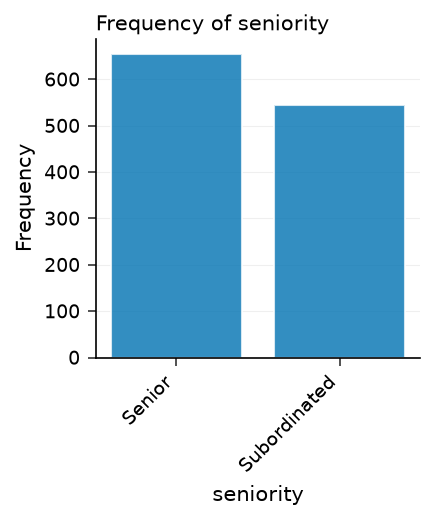

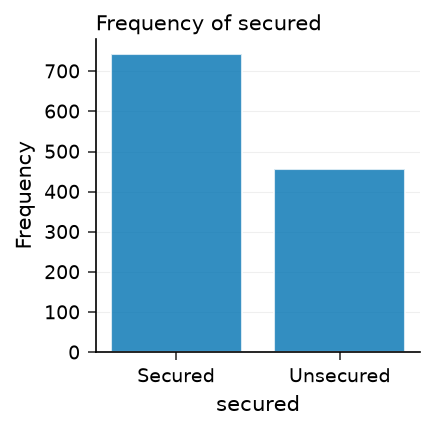

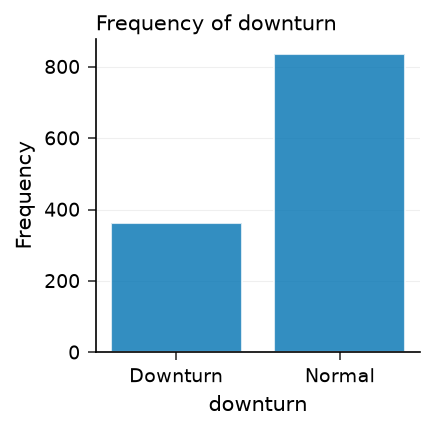

In [2]:
proc means data=lgd_portfolio n mean std min p10 p25 median p75 p90 max maxdec=3;
    var lgd ltv collateral exposure;
run;

proc freq data=lgd_portfolio;
    tables seniority secured downturn;
run;

## Step 3 - Fit LGD across five quantiles

We fit the conditional 10th, 25th, 50th, 75th, and 90th percentiles of LGD in a single call. The `CLASS` statement declares the categorical risk attributes, and `QUANTILE=0.1 0.25 0.5 0.75 0.9` requests all five fits at once. `CI=SPARSITY` computes confidence limits from the sparsity function, a standard choice under near-iid errors.

Reading the coefficients across the five blocks below is the whole point. The `SECURED UNSECURED` coefficient (the extra LGD carried by an unsecured facility relative to secured) walks steadily up the distribution:

| Quantile | `SECURED UNSECURED` estimate | 95% CI |
|---------:|-----------------------------:|:-------|
| 0.10 | 0.015 | (-0.011, 0.040) |
| 0.25 | 0.069 | ( 0.043, 0.095) |
| 0.50 | 0.144 | ( 0.120, 0.168) |
| 0.75 | 0.185 | ( 0.160, 0.211) |
| 0.90 | 0.215 | ( 0.175, 0.255) |

At the body of the distribution, security barely matters (and at the 10th percentile its confidence interval still includes zero); in the tail it adds roughly 0.21 to LGD. `COLLATERAL` stays protective across the board (coefficients between about -0.21 and -0.29), while `LTV` is large at every quantile (around 0.40-0.50) - a broad-based driver. The quantile-*dependence* of the security effect is the signal OLS would miss.

In [3]:
proc quantreg data=lgd_portfolio ci=sparsity;
    class seniority secured downturn;
    model lgd = ltv collateral seniority secured downturn
          / quantile=0.1 0.25 0.5 0.75 0.9;
run;


The QUANTREG Procedure

Quantile: 0.1000
CI Method: SPARSITY
Dependent Variable: lgd

Parameter           Estimate       StdErr        Lower        Upper
Intercept             0.1314       0.0497       0.0341       0.2288
LTV                   0.4049       0.0440       0.3188       0.4911
COLLATERAL           -0.2074       0.0261      -0.2586      -0.1563
SENIORITY SENIOR      -0.1043       0.0129      -0.1296      -0.0790
SECURED UNSECURED       0.0146       0.0132      -0.0112       0.0405
DOWNTURN NORMAL      -0.0833       0.0139      -0.1106      -0.0560
Intercept             0.2963       0.0493       0.1997       0.3928
LTV                   0.4057       0.0436       0.3203       0.4912
COLLATERAL           -0.2776       0.0259      -0.3283      -0.2268
SENIORITY SENIOR      -0.1113       0.0128      -0.1364      -0.0863
SECURED UNSECURED       0.0689       0.0131       0.0433       0.0946
DOWNTURN NORMAL      -0.1298       0.0138      -0.1568      -0.1027
Intercept             0

NOTE: PROC QUANTREG data=lgd_portfolio

NOTE: PROC QUANTREG completed.


## Step 4 - Plot the quantile process for the unsecured penalty

The visual diagnostic of quantile regression is the **quantile-process plot**: a coefficient traced across the quantile range with its confidence band. We capture the per-quantile parameter estimates with `ODS OUTPUT ParameterEstimates=`, isolate the `SECURED` rows, and draw the trajectory with `PROC SGPLOT`.

The plot makes the table in Step 3 concrete. The point estimate rises monotonically from near zero at the 10th percentile to about 0.215 at the 90th, and the lower edge of the 95% band lifts clear of zero between the 10th and 25th percentiles - so the unsecured penalty is statistically distinguishable from zero across essentially the entire upper four-fifths of the loss distribution, but is indistinguishable from zero right at the bottom. That is the textbook downturn-LGD picture: the driver that is borderline at the very best recoveries becomes decisive in the tail.


The QUANTREG Procedure

Quantile: 0.1000
CI Method: SPARSITY
Dependent Variable: lgd

Parameter           Estimate       StdErr        Lower        Upper
Intercept             0.1314       0.0497       0.0341       0.2288
LTV                   0.4049       0.0440       0.3188       0.4911
COLLATERAL           -0.2074       0.0261      -0.2586      -0.1563
SENIORITY SENIOR      -0.1043       0.0129      -0.1296      -0.0790
SECURED UNSECURED       0.0146       0.0132      -0.0112       0.0405
DOWNTURN NORMAL      -0.0833       0.0139      -0.1106      -0.0560
Intercept             0.2963       0.0493       0.1997       0.3928
LTV                   0.4057       0.0436       0.3203       0.4912
COLLATERAL           -0.2776       0.0259      -0.3283      -0.2268
SENIORITY SENIOR      -0.1113       0.0128      -0.1364      -0.0863
SECURED UNSECURED       0.0689       0.0131       0.0433       0.0946
DOWNTURN NORMAL      -0.1298       0.0138      -0.1568      -0.1027
Intercept             0

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC QUANTREG data=lgd_portfolio

NOTE: PROC QUANTREG completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA secured_path


NOTE: Read 30 rows from pe.
NOTE: Wrote secured_path (5 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=secured_path

NOTE: PROC PRINT completed: 5 observations printed, 5 variables
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=secured_path

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


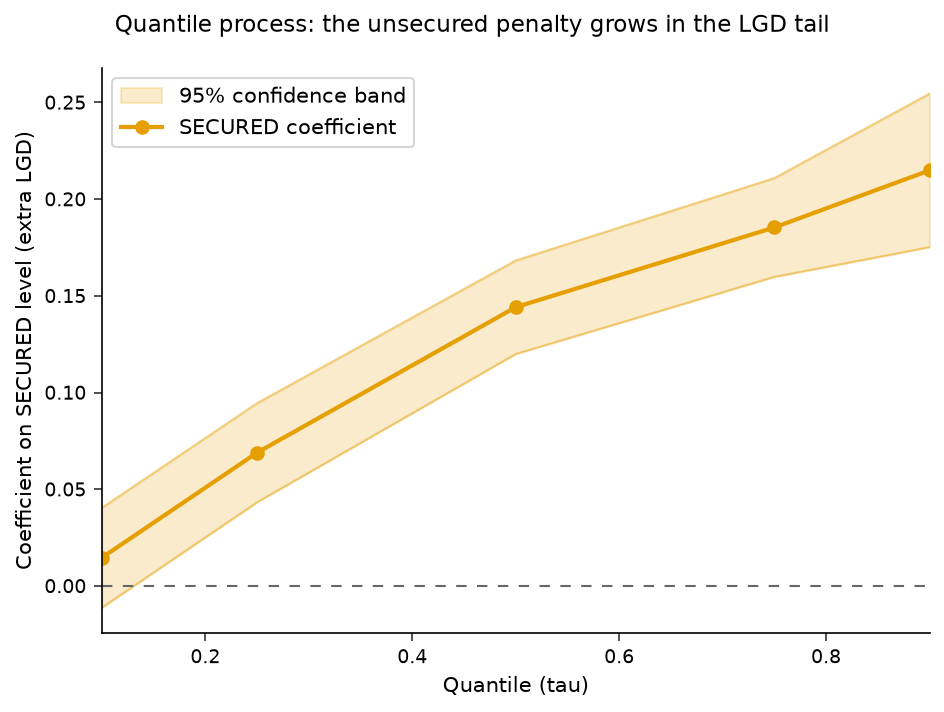

In [4]:
ods output ParameterEstimates=pe;
proc quantreg data=lgd_portfolio ci=sparsity;
    class seniority secured downturn;
    model lgd = ltv collateral seniority secured downturn
          / quantile=0.1 0.25 0.5 0.75 0.9;
run;
ods output close;

/* Keep just the unsecured-vs-secured coefficient at each quantile */
data secured_path;
    set pe;
    where parameter =: "SECURED";
run;

proc print data=secured_path noobs;
    var quantile parameter estimate lower upper;
run;

ods graphics on;
proc sgplot data=secured_path;
    band   x=quantile lower=lower upper=upper
           / transparency=0.6 legendlabel="95% confidence band";
    series x=quantile y=estimate
           / markers lineattrs=(thickness=2)
             legendlabel="SECURED coefficient";
    refline 0 / axis=y lineattrs=(pattern=shortdash);
    xaxis label="Quantile (tau)";
    yaxis label="Coefficient on SECURED level (extra LGD)";
    title "Quantile process: the unsecured penalty grows in the LGD tail";
run;

## Step 5 - Estimate the tail penalty for unsecured exposures

Using the upper-tail (90th-percentile) fit, we estimate the LGD differential between unsecured and secured facilities with a 99% confidence interval via the `ESTIMATE` statement. This is the kind of number a capital model reports directly: in a severe-loss scenario, an unsecured facility loses this many extra cents on the dollar.

The estimate is **0.215** with a 99% confidence interval of **(0.169, 0.261)** - comfortably above zero, confirming the tail penalty is real and material, not a sampling artifact.

In [5]:
proc quantreg data=lgd_portfolio ci=sparsity;
    class seniority secured downturn;
    model lgd = ltv collateral seniority secured downturn
          / quantile=0.9;
    estimate 'Unsecured vs Secured (90th pct LGD)'
             secured 1 -1 / cl alpha=0.01;
run;


The QUANTREG Procedure

Quantile: 0.9000
CI Method: SPARSITY
Dependent Variable: lgd

Parameter           Estimate       StdErr        Lower        Upper
Intercept             0.6262       0.0763       0.4767       0.7758
LTV                   0.4511       0.0675       0.3187       0.5835
COLLATERAL           -0.2810       0.0401      -0.3596      -0.2024
SENIORITY SENIOR      -0.1147       0.0198      -0.1536      -0.0759
SECURED UNSECURED       0.2149       0.0203       0.1752       0.2546
DOWNTURN NORMAL      -0.2360       0.0214      -0.2780      -0.1941

Estimates

Label                    Estimate       StdErr      LowerCL      UpperCL
----------------------------------------------------------------------
Unsecured vs Secured (90th pct LGD)       0.2149       0.0179       0.1688       0.2609
----------------------------------------------------------------------



NOTE: PROC QUANTREG data=lgd_portfolio

NOTE: PROC QUANTREG completed.


## Step 6 - Write fitted tail LGD back to the portfolio

For downstream capital reporting we attach each loan's fitted LGD at the **90th percentile** - the downturn-LGD quantile - using the `OUTPUT` statement. Each input loan gets one fitted value `lgd_p90` and a residual.

The fitted tail LGD averages **0.656** across the book with a 90th percentile of **0.972**, well above the realized mean LGD of 0.430: this is the conditional severe-loss surface a downturn-LGD calibration would carry into economic-capital aggregation. The printed rows show the loan-level fitted tail loss next to the realized loss.

In [6]:
proc quantreg data=lgd_portfolio ci=none;
    class seniority secured downturn;
    model lgd = ltv collateral seniority secured downturn
          / quantile=0.9;
    output out=lgd_tail predicted=lgd_p90 residual=resid;
run;

proc means data=lgd_tail n mean p90 max maxdec=3;
    var lgd lgd_p90;
run;

proc print data=lgd_tail(obs=10) noobs;
    var ltv collateral lgd lgd_p90 resid;
run;


The QUANTREG Procedure

Quantile: 0.9000
CI Method: NONE
Dependent Variable: lgd

Parameter           Estimate
Intercept             0.6262
LTV                   0.4511
COLLATERAL           -0.2810
SENIORITY SENIOR      -0.1147
SECURED UNSECURED       0.2149
DOWNTURN NORMAL      -0.2360

                                                  The MEANS Procedure

 Variable          N        Mean   90th Pctl     Maximum
 -------------------------------------------------------
 LGD            1200       0.430       0.819       1.000
 LGD_P90        1200       0.656       0.972       1.352
 -------------------------------------------------------


         LTV    COLLATERAL           LGD       LGD_P90          RESID
------------  ------------  ------------  ------------  -------------
1.0394899346  0.4581513058  0.6978129975  0.9664321014  -0.2686191039
0.6457811284  1.0699852838   0.301829006  0.5957273051  -0.2938982991
0.8865147258  0.8127059825  0.5460732373  0.6618845255  -0.1158112882
0.

NOTE: PROC QUANTREG data=lgd_portfolio

NOTE: PROC QUANTREG completed.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=lgd_tail

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Interpreting the results

- **The mean is not the story.** The realized mean LGD is 0.430, but the conditional 90th-percentile fit pushes average fitted loss to 0.656. An OLS model - anchored to the conditional mean - would understate exactly the losses that drive regulatory capital.
- **Security protects the tail, not the center.** The `SECURED UNSECURED` coefficient is statistically indistinguishable from zero at the 10th percentile (+0.015, 95% CI -0.011 to 0.040) yet reaches +0.215 at the 90th. The quantile-process plot in Step 4 shows the confidence band lifting clear of zero just past the 10th percentile - so a single averaged "unsecured penalty" would understate the tail and overstate the very best recoveries.
- **Collateral is a steady cushion.** Its coefficient stays negative (roughly -0.21 to -0.29) across all five quantiles, the kind of broad-based protection a mean model captures adequately. Quantile regression confirms it does *not* need a tail-specific adjustment, which is itself a useful finding.
- **The ESTIMATE gives a reportable downturn figure** - the extra loss fraction borne by unsecured facilities in the upper tail, 0.215 with a 99% interval of (0.169, 0.261).
- **The OUTPUT step** produces a loan-level, tail-quantile LGD column (mean 0.656, 90th percentile 0.972) that feeds straight into expected-loss and economic-capital aggregation.

**Bottom line:** for LGD, where capital lives in the tail, `PROC QUANTREG` estimates the loss distribution where it matters instead of collapsing it to a single mean, and the quantile-process view tells you precisely which drivers - here, facility security - demand a separate downturn calibration.